<a href="https://colab.research.google.com/github/dmarrazzo/fin-test/blob/main/Certificato_IT0006773326.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Certificato 37m Wof Memory Phoenix Autocall on EURO STOXX 50 Price EUR, iShares China Large-Cap ETF, S&P 500 INDEX, Nikkei 225 in EUR

EURO STOXX 50 Price EUR, iShares China Large-Cap ETF, S&P 500 INDEX, Nikkei 225

## Carica Dati

In [ ]:
#pip install yfinance

In [1]:
import yfinance as yf
from datetime import date
import pandas as pd
from typing_extensions import final
from dateutil.relativedelta import relativedelta

# Parameters
barrier = 0.55 # coupon barrier
capital_barrier = 0.50
coupon = 0.0761 # percentage
capital = 10000.0

# iShares China Large-Cap ETF, S&P 500 INDEX, Nikkei 225
tickers = ["^STOXX50E","FXI","^GSPC", "^N225"]

#first_date_available = "2012-04-27"
first_date_available = "2026-07-16"
closing_prices = yf.download(tickers, start=first_date_available, auto_adjust=True)['Close']
display(closing_prices.head())

[*********************100%***********************]  4 of 4 completed


Ticker,FXI,^GSPC,^N225,^STOXX50E
Date,,,,
2026-07-16,34.529999,7533.77002,66835.539062,6283.609863


In [ ]:
first_valid_date = None
for index, row in closing_prices.iterrows():
    if not row.isnull().any():
        first_valid_date = index.date()
        break

if first_valid_date:
    print(f"The first date with data for all tickers is: {first_valid_date}")
else:
    print("No date found where all tickers have data.")

The first date with data for all tickers is: 2013-01-04


## Simulazione partendo da primo giorno dati


### Funzione per il calcolo dei prezzi nei giorni di valutazione

In [ ]:
def get_simulated_closing_prices(simulation_start_date):
    # Genera le date teoriche di valutazione (una al mese per 36 mesi)
    theoretical_dates = pd.to_datetime([pd.to_datetime(simulation_start_date) + relativedelta(months=i) for i in range(36)])

    # Trova gli indici numerici delle date nel dataset usando backfill
    # get_indexer restituisce la posizione intera del valore più vicino (bfill)
    indices = closing_prices.index.get_indexer(theoretical_dates, method='bfill')

    # Filtra gli indici validi (quelli non -1, che indicano valori fuori range)
    valid_indices = indices[indices != -1]

    # Recupera i timestamp effettivi presenti nell'indice usando le posizioni trovate
    actual_dates = closing_prices.index[valid_indices].unique()

    return closing_prices.loc[actual_dates]

simulated_closing_prices_evaluated = get_simulated_closing_prices(first_date_available)
display(simulated_closing_prices_evaluated)

,^GSPC,^N225,EURO STOXX Banks
Date,,,
2013-01-02,1462.420044,NaN,117.14
2013-02-01,1513.170044,11191.339844,123.34
2013-03-01,1518.199951,11606.379883,112.53
2013-04-02,1570.250000,12003.429688,104.63
2013-05-01,1582.699951,13799.349609,111.89
2013-06-03,1640.420044,13261.820312,115.30
2013-07-01,1614.959961,13852.500000,102.90
2013-08-01,1706.869995,14005.769531,116.98
2013-09-02,1632.969971,13572.919922,119.23


In [ ]:
from datetime import date, timedelta, datetime

def compute_total_return(strike_date):

    strike_coefficient = 1.0 # Initialize locally for each function call

    # dataframe with barrier prices
    strike_prices = closing_prices.loc[pd.Timestamp(strike_date)]
    barrier_price = strike_prices * barrier

    barrier_hit_dates = []

    total_coupon = 0
    coupon_memory = 0
    reimboursement = 0
    duration = 0

    barrier_hitted = False
    strike_hitted = False

    simulated_closing_prices_evaluated = get_simulated_closing_prices(strike_date)

    for i, (index, row) in enumerate(simulated_closing_prices_evaluated.iterrows()):
        duration = i + 1
        # Check if any ticker's price in the row is less than or equal to its corresponding barrier_price
        if (row <= barrier_price).any():
            barrier_hit_dates.append(index.date())
            coupon_memory += coupon
        else:
            total_coupon += coupon_memory
            coupon_memory = 0
            total_coupon += coupon

        # scadenza anticipata dopo 6 mesi (i partendo da 0, 6 è il settimo mese)
        if i >= 6 and (row > strike_prices*strike_coefficient).all():
            total_coupon += coupon_memory
            coupon_memory = 0
            total_coupon += coupon
            strike_hitted = True
            strike_coefficient -= 0.01

            break

    # final barrier hitted
    if coupon_memory > 0:
        #print("Final barrier hitted")
        # lowest of last simulated_closing_prices_evaluated divided by the strike price
        ror_series = simulated_closing_prices_evaluated.iloc[-1] / strike_prices
        #print(ror_series)
        reimboursement = capital * ror_series.min()
        barrier_hitted = True
    else:
        reimboursement = capital

    # print(f"row: {row}")
    # print(f"strike_prices: {strike_prices}")
    # print(f"barrier_price: {barrier_price}")
    # print(f"Total return: {total_coupon+reimboursement}")
    # if barrier_hit_dates:
    #     print(f"Barrier hit on the following dates: {barrier_hit_dates}")
    # else:
    #     print("Barrier not hit on any simulated evaluation date.")

    total_return = reimboursement + total_coupon

    return total_return, barrier_hitted, strike_hitted, duration

compute_total_return("2014-01-09")

(11190.0, False, True, 16)

## Calcola ritorni

In [ ]:
from tqdm.auto import tqdm

# Definiamo l'intervallo di date utilizzando pandas per maggiore efficienza
start_date = pd.Timestamp(2013, 1, 5)
end_date = pd.Timestamp(2023, 4, 4)

# Filtriamo le date di strike che sono effettivamente presenti nel dataset
available_strike_dates = closing_prices.index[(closing_prices.index >= start_date) & (closing_prices.index <= end_date)]

results_list = []
barrier_count = 0
strike_count = 0

# Utilizziamo un ciclo sulle date valide con una barra di progresso
for strike_date in tqdm(available_strike_dates, desc="Simulazione in corso"):
    total_return, barrier_hitted, strike_hitted, duration = compute_total_return(strike_date)

    results_list.append({
        'strike_date': strike_date,
        'total_return': total_return,
        'barrier_hitted': barrier_hitted,
        'strike_hitted': strike_hitted,
        'duration': duration
    })

    if barrier_hitted:
        barrier_count += 1
    if strike_hitted:
        strike_count += 1

# Create the DataFrame
simulation_results = pd.DataFrame(results_list)
display(simulation_results.head())

Simulazione in corso:   0%|          | 0/2628 [00:00<?, ?it/s]

,strike_date,total_return,barrier_hitted,strike_hitted,duration
0,2013-01-07,10700.0,False,True,9
1,2013-01-08,10700.0,False,True,9
2,2013-01-09,10770.0,False,True,10
3,2013-01-10,10770.0,False,True,10
4,2013-01-11,10700.0,False,True,9


Total Simulations: 2628
Barrier hitted: 81
Strike hitted: 2180
Average Duration: 15.40 months

Returns Statistics:
count     2628.000000
mean     10953.158976
std       1052.324787
min       5892.111745
25%      10560.000000
50%      10630.000000
75%      11470.000000
max      12590.000000
Name: total_return, dtype: float64


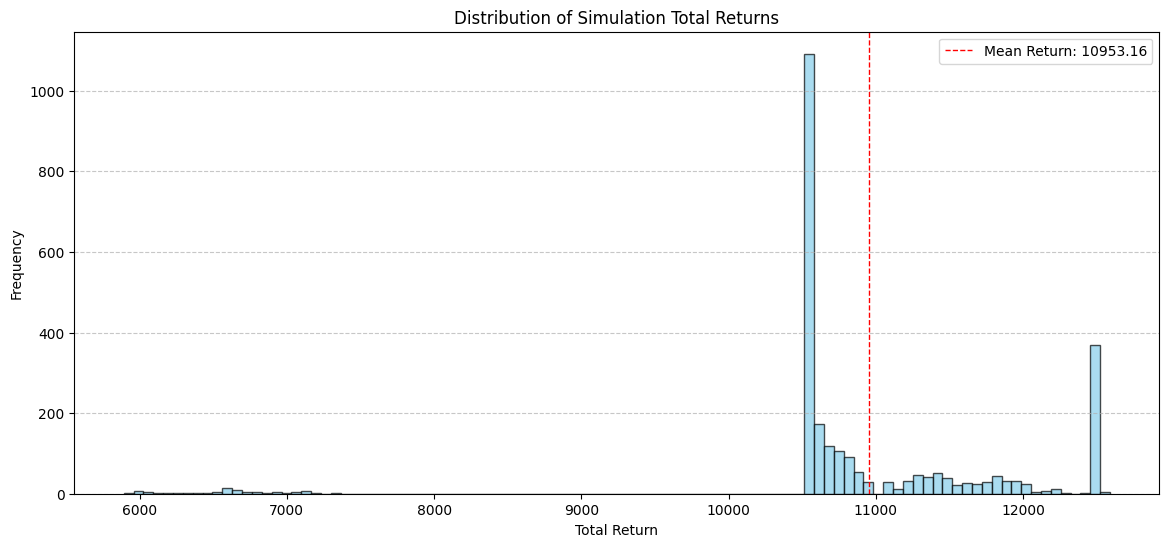

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate summary statistics from the simulation_results DataFrame
barrier_count = simulation_results['barrier_hitted'].sum()
strike_count = simulation_results['strike_hitted'].sum()
returns_serie = simulation_results['total_return']
average_duration = simulation_results['duration'].mean()

print(f"Total Simulations: {len(simulation_results)}")
print(f"Barrier hitted: {barrier_count}")
print(f"Strike hitted: {strike_count}")
print(f"Average Duration: {average_duration:.2f} months")
print("\nReturns Statistics:")
print(returns_serie.describe())

# Visualization
plt.figure(figsize=(14, 6))
plt.hist(returns_serie, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(returns_serie.mean(), color='red', linestyle='dashed', linewidth=1, label=f'Mean Return: {returns_serie.mean():.2f}')
plt.title('Distribution of Simulation Total Returns')
plt.xlabel('Total Return')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [ ]:
below_capital_count = (simulation_results['total_return'] < capital).sum()
probability_below_capital = (below_capital_count / len(simulation_results)) * 100

# Calculate Value at Risk (VaR) and Conditional Value at Risk (CVaR)
alfa = 0.05 # 5% VaR
var = simulation_results['total_return'].quantile(alfa) # Get a scalar VaR
cvar = simulation_results[simulation_results['total_return'] <= var]['total_return'].mean()

print(f"\nRisk Statistics:")
print(f"Returns below capital ({capital}): {below_capital_count} times")
print(f"Probability of returns below capital: {probability_below_capital:.2f}%")
print(f"Minimum Return: {returns_serie.min():.2f}")
print(f"Maximum Return: {returns_serie.max():.2f}")
print(f"Value at Risk (VaR) at {alfa*100}%: {var:.2f}")
print(f"Conditional Value at Risk (CVaR) at {alfa*100}%: {cvar:.2f}")


Risk Statistics:
Returns below capital (10000.0): 81 times
Probability of returns below capital: 3.08%
Minimum Return: 5892.11
Maximum Return: 12590.00
Value at Risk (VaR) at 5.0%: 10560.00
Conditional Value at Risk (CVaR) at 5.0%: 10286.28
